In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

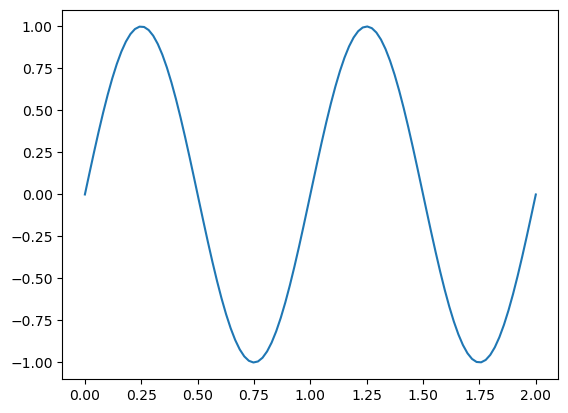

In [2]:
x = np.linspace(0, 2, 100)

y = np.sin(2 * np.pi * x)

plt.plot(x, y)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sirs_two_waves(
    t_max=365,
    dt=0.1,
    # wave 1
    t1=70.0, w1=18.0, a1=1.0,
    # wave 2
    t2=230.0, w2=25.0, a2=0.75,
    # shaping / realism
    baseline=0.01,
    tail_decay=0.002,
    noise=0.02,
    seed=0,
    scale=1.0,
    show=True,
    ax=None,
):
    """
    Produce a plausible SIRS-like infection time series with two waves.
    Uses two skewed "epidemic pulses" + small baseline + mild noise.

    Returns
    -------
    t : np.ndarray
    I : np.ndarray
        Infection intensity (arbitrary units, scaled by `scale`).
    """

    rng = np.random.default_rng(seed)
    t = np.arange(0.0, t_max + dt, dt)

    def skew_pulse(t, t0, width, amp, skew=0.6):
        # Left side rises faster, right side decays slower (typical epidemic shape)
        left = np.exp(-0.5 * ((t - t0) / (width * (1 - skew))) ** 2)
        right = np.exp(-0.5 * ((t - t0) / (width * (1 + skew))) ** 2)
        return amp * np.where(t <= t0, left, right)

    I = (
        baseline
        + skew_pulse(t, t1, w1, a1, skew=0.55)
        + skew_pulse(t, t2, w2, a2, skew=0.65)
    )

    # Gentle long-term decay so it doesn't stay artificially high forever
    I *= np.exp(-tail_decay * t)

    # Mild multiplicative noise (keeps positivity)
    if noise > 0:
        I *= np.exp(rng.normal(0.0, noise, size=t.size))

    I *= scale

    if show:
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.plot(t, I)
        plt.tight_layout()
        plt.show()

    return t, I


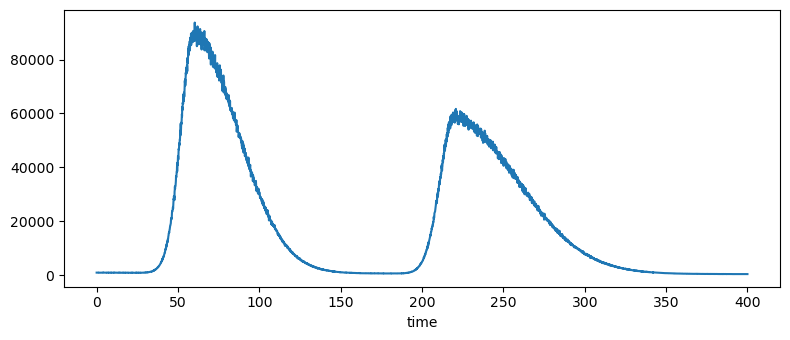

(array([0.000e+00, 1.000e-01, 2.000e-01, ..., 3.998e+02, 3.999e+02,
        4.000e+02]),
 array([1002.51776881,  997.1619378 , 1012.48575742, ...,  457.55338305,
         444.60743138,  460.06743665]))

In [6]:
plot_sirs_two_waves(t_max=400, t1=60, t2=220, a2=0.9, scale=1e5)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cases_and_human_response(
    t_max=365,
    dt=0.2,

    # --- Cases: two stylized waves ---
    t1=70.0,  w1=18.0, a1=1.0,
    t2=230.0, w2=28.0, a2=0.75,
    baseline=0.01,
    tail_decay=0.0015,
    cases_noise=0.02,
    seed=0,
    cases_scale=1.0,

    # --- Human response: delayed + smoothed + saturating ---
    delay=14.0,          # days of behavioral/policy delay
    smooth=10.0,         # days of "inertia" / smoothing
    threshold=0.25,      # where response starts ramping up (in cases' normalized units)
    steepness=12.0,      # higher => sharper ramp
    max_response=1.0,    # response upper bound
    response_floor=0.0,  # minimum response level
):
    """
    Qualitative plot for talks:
      - cases(t): two epidemic-like waves
      - response(t): delayed, smoothed, saturating function of cases(t)

    Returns: t, cases, response
    """

    rng = np.random.default_rng(seed)
    t = np.arange(0.0, t_max + dt, dt)

    def skew_pulse(t, t0, width, amp, skew=0.6):
        left = np.exp(-0.5 * ((t - t0) / (width * (1 - skew))) ** 2)
        right = np.exp(-0.5 * ((t - t0) / (width * (1 + skew))) ** 2)
        return amp * np.where(t <= t0, left, right)

    # --- cases ---
    cases = (
        baseline
        + skew_pulse(t, t1, w1, a1, skew=0.55)
        + skew_pulse(t, t2, w2, a2, skew=0.65)
    )
    cases *= np.exp(-tail_decay * t)

    if cases_noise > 0:
        cases *= np.exp(rng.normal(0.0, cases_noise, size=t.size))

    cases *= cases_scale

    # normalize internally for response shaping (keeps knobs stable across cases_scale)
    c = cases / (cases.max() + 1e-12)

    # --- delayed input ---
    shift_steps = int(round(delay / dt))
    c_delayed = np.roll(c, shift_steps)
    c_delayed[:shift_steps] = c[0]

    # --- smoothing (simple causal exponential moving average) ---
    # alpha chosen so time constant ~ smooth
    alpha = 1.0 - np.exp(-dt / max(smooth, 1e-9))
    c_smooth = np.empty_like(c_delayed)
    c_smooth[0] = c_delayed[0]
    for i in range(1, len(c_delayed)):
        c_smooth[i] = (1 - alpha) * c_smooth[i - 1] + alpha * c_delayed[i]

    # --- saturating response: logistic mapping to [floor, max] ---
    # logistic(x) = 1 / (1 + exp(-k*(x-th)))
    s = 1.0 / (1.0 + np.exp(-steepness * (c_smooth - threshold)))
    response = response_floor + (max_response - response_floor) * s

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(9, 3.8))
    ax1.plot(t, cases, label="cases (stylized)")
    ax1.set_xlabel("time")
    ax1.set_ylabel("cases (a.u.)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(t, response, linestyle="--", label="human response")
    ax2.set_ylabel("response (0–1)")

    # combined legend
    lines, labels = [], []
    for ax in (ax1, ax2):
        l, lab = ax.get_legend_handles_labels()
        lines += l
        labels += lab
    ax1.legend(lines, labels, loc="upper right")

    plt.title("Qualitative two-wave cases + delayed human response")
    plt.tight_layout()
    plt.show()

    return t, cases, response


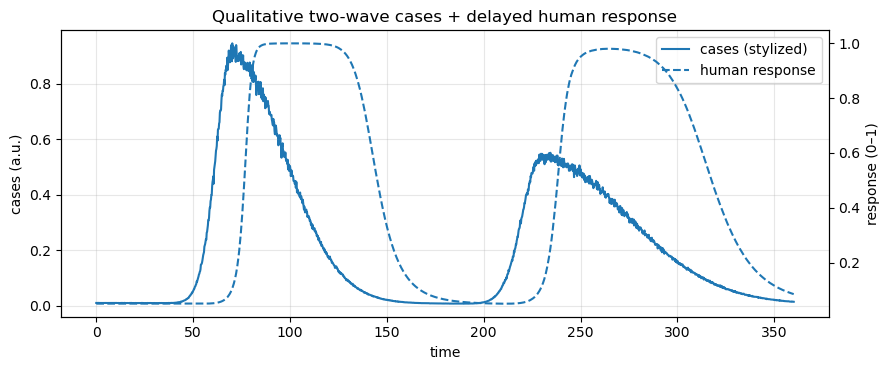

In [20]:
t, cases, response = plot_cases_and_human_response(
    t_max=360,
    delay=14, smooth=12,
    threshold=0.22, steepness=14
)


In [34]:
response = response - np.min(response)

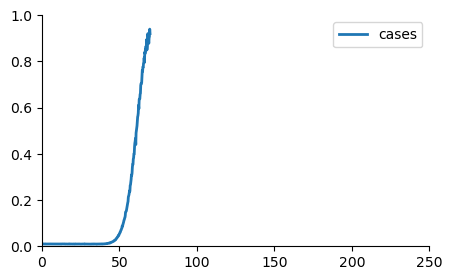

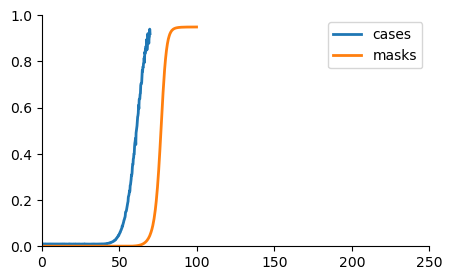

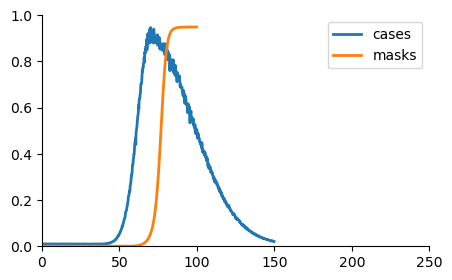

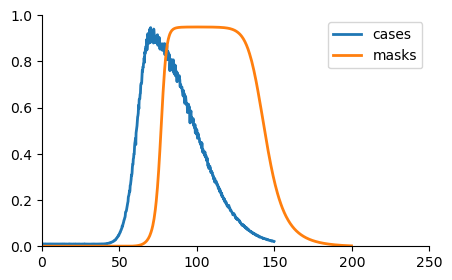

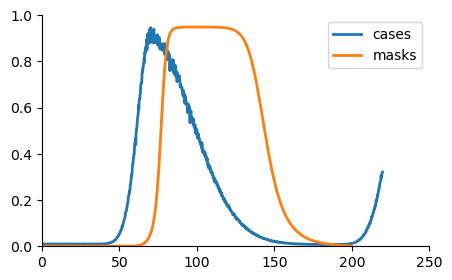

In [50]:
Lx = 5
Ly = 3

phase1 = t < 60
phase2 = t < 150
phase3 = t < 250

phase_1 = t< 100
phase_2 = t < 220

fig, ax = plt.subplots(figsize=(Lx, Ly))
ax.plot(t[t<70], cases[t<70], linewidth=2, label='cases')
ax.set_xlim(0, 250)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right')


fig, ax = plt.subplots(figsize=(Lx, Ly))
ax.plot(t[t < 70], cases[t < 70], linewidth=2, label='cases')
ax.plot(t[phase_1], response[phase_1], linewidth=2, label='masks')
ax.set_xlim(0, 250)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')


fig, ax = plt.subplots(figsize=(Lx, Ly))
ax.plot(t[t < 150], cases[t < 150], linewidth=2, label='cases')
ax.plot(t[phase_1], response[phase_1], linewidth=2, label='masks')
ax.set_xlim(0, 250)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')


fig, ax = plt.subplots(figsize=(Lx, Ly))
ax.plot(t[t < 150], cases[t < 150], linewidth=2, label='cases')
ax.plot(t[t < 200], response[t < 200], linewidth=2, label='masks')
ax.set_xlim(0, 250)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')


fig, ax = plt.subplots(figsize=(Lx, Ly))
ax.plot(t[t < 220], cases[t < 220], linewidth=2, label='cases')
ax.plot(t[t < 200], response[t < 200], linewidth=2, label='masks')
ax.set_xlim(0, 250)
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def WnR():
    t = np.linspace(0, 200, 800)

    # --- epidemic wave (purely schematic) ---
    cases = np.exp(-0.5 * ((t - 70) / 20) ** 2)

    # --- human response: delayed + smoothed + saturating ---
    delay = 14
    response_input = np.interp(t - delay, t, cases, left=cases[0])

    alpha = 0.05  # inertia
    response = np.zeros_like(response_input)
    for i in range(1, len(response)):
        response[i] = (1 - alpha) * response[i - 1] + alpha * response_input[i]

    response = 1 / (1 + np.exp(-12 * (response - 0.3)))

    return t, cases, response

In [17]:
t, cases, response = WnR()

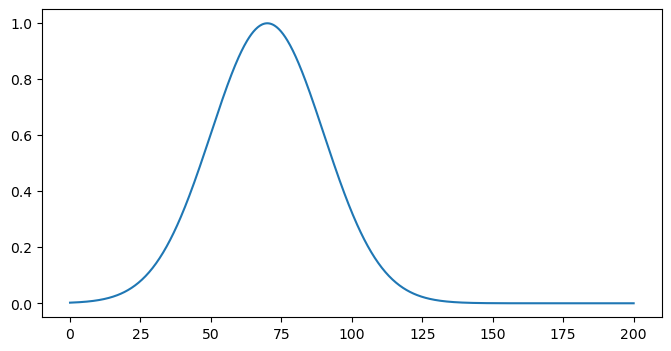

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t, cases)

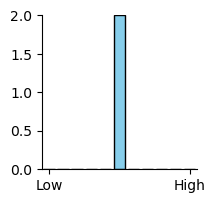

In [65]:
# make a histogram where there are 10 bins. First and last bins are 1, and the others are 0.

values = [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.bar(range(11), values, color='skyblue', edgecolor='black')
ax.set_ylim(0,2)
ax.set_xlim(-0.5, 10.5)
ax.set_xticks([0, 10])
ax.set_xticklabels(['Low', 'High'])

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 

In [ ]:
# make a histogram where there are 10 bins. First and last bins are 1, and the others are 0.

values = [1, 0, 0, 0, 0, 0, 0, 0, 0, 1]

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.bar(range(10), values, color='skyblue', edgecolor='black')
ax.set_ylim(0,2)
ax.set_xlim(-0.5, 9.5)
ax.set_xticks([0, 9])
ax.set_xticklabels(['Low', 'High'])

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


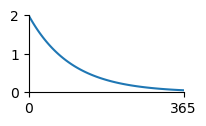

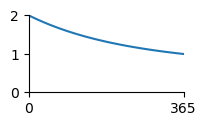

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(2, 1))
x = np.linspace(0, 365, 100)
y1 = 2 * np.exp(-0.01 * x)
ax.plot(x, y1)
ax.set_ylim(0,2)
ax.set_xlim(0, 365)
ax.set_xticks([0, 365])
ax.set_xticklabels(['0', '365'])

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


fig, ax = plt.subplots(1, 1, figsize=(2, 1))
x = np.linspace(0, 365, 100)
y2 = np.exp(-0.01/2 * x) +np.exp(-0.001/2 * x)

plt.plot(x, y2)
ax.set_ylim(0,2)
ax.set_xlim(0, 365)
ax.set_xticks([0, 365])
ax.set_xticklabels(['0', '365'])

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)




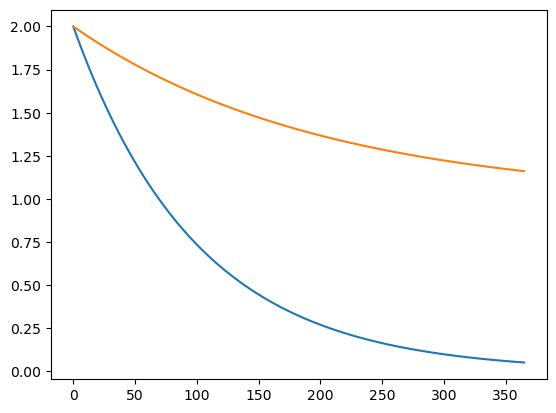

In [ ]:

plt.plot(x, y1)



In [6]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *
from src.utils.distributions import *
import numpy as np



from src.utils.batch_sweep import sweep_two_parameters

# Import the matrix creation function
from src.utils.Contact_Matrix import create_contact_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
N = 20
DI = my_beta_asymmetric(50, 50, N)

mu_max = 0.8
tau_max = 0.19799999999999998
vaccination_rate_max = 0.1

mus = np.linspace(0+mu_max/N/2, mu_max-mu_max/N/2, N)
taus = np.linspace(0+tau_max/N/2, tau_max-tau_max/N/2, N)
xis = np.linspace(0+vaccination_rate_max/N/2, vaccination_rate_max-vaccination_rate_max/N/2, N)


bm = 0.45
g = 0.1

In [26]:
def R0_SIRM(bm, g, DI, mus):
    

    R0_h0 = bm/g * (1 - np.sum(DI * mus))
    R0_hinf = bm/g * (1 - np.min(mus))

    return R0_h0, R0_hinf

In [29]:
R0_h0, R0_hinf = R0_SIRM(bm, g, DI, mus)
print(f"R0_h0: {R0_h0:.3f}, R0_hinf: {R0_hinf:.3f}")

R0_h0: 2.700, R0_hinf: 4.410


In [24]:
def r0_SIRT_h0(b, g, DI, taus):
    R0_0 = b * np.sum(DI/(g + taus))
    R0_inf = b / (g + np.min(taus))
    return R0_0, R0_inf


b = 0.15
g = 0.1
R0_0, R0_inf = r0_SIRT_h0(b, g, DI, taus)
print("R0 at h=0:", R0_0)
print("R0 at h=inf:", R0_inf)

R0 at h=0: 0.96297896
R0 at h=inf: 1.4292520247737017


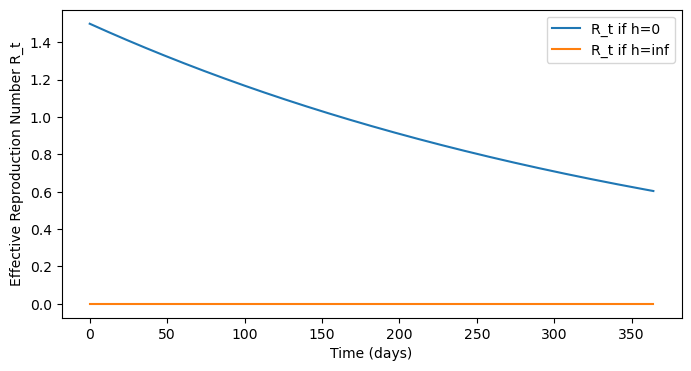

In [ ]:
def rt_SIRV(b, g, DI, xis):
    t = np.arange(0, 365, 1)
    rt_h0 = np.zeros(len(t))
    rt_hinf = np.zeros(len(t))
    for i in range(len(t)):
        S = DI * np.exp(-xis * t[i])
        rt_h0[i] = b/(g) * np.sum(S)
        rt_h0[i] = b/(g) * np.max(np.exp(-xis * t[i]))


    return t, rt_h0, rt_hinf

t, rt_h0, rt_hinf = rt_SIRV(b, g, DI, xis)


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, rt_h0, label='R_t if h=0')
ax.plot(t, rt_hinf, label='R_t if h=inf')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Effective Reproduction Number R_t')
ax.legend()

fig.savefig('figures/Fig_SI/R_t_over_time.pdf', dpi=300)